In [8]:
import qflib as qf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
plt.style.use('ggplot')

# Market
qf.ycCreate("flat2pct", [0.5, 1.0, 2.0], [0.02, 0.02, 0.02], 0)

# Parameters
spot    = 100.0
strike  = 100.0
T       = 1.0
divY    = 0.0
simVol  = 0.20
nPaths  = 200_000
pgType  = 0  # Euler
rngType = 1  # Mersenne Twister
histNbins = 80

variants  = [(0, +1, "EuCall"), (0, -1, "EuPut"),
             (1, +1, "DiCall"), (1, -1, "DiPut")]
hist_range = {"EuCall": (-20, 20), "EuPut": (-20, 20),
              "DiCall":  (-1,  1), "DiPut":  (-1,  1)}  # tighter: digital P&L in ~[-0.5,0.5] for high N
hist_nbins = {"EuCall": 80, "EuPut": 80,
              "DiCall": 400, "DiPut": 400}  # 400 bins over [-1,1]: bin width=0.005

mtm_vols  = [0.10, 0.20, 0.30, 0.40]
freqs     = [12, 26, 52, 104, 252, 500, 1000]


## Volatility Sweep
Fixed hedge frequency (24/yr). Mark-to-market vol varies.

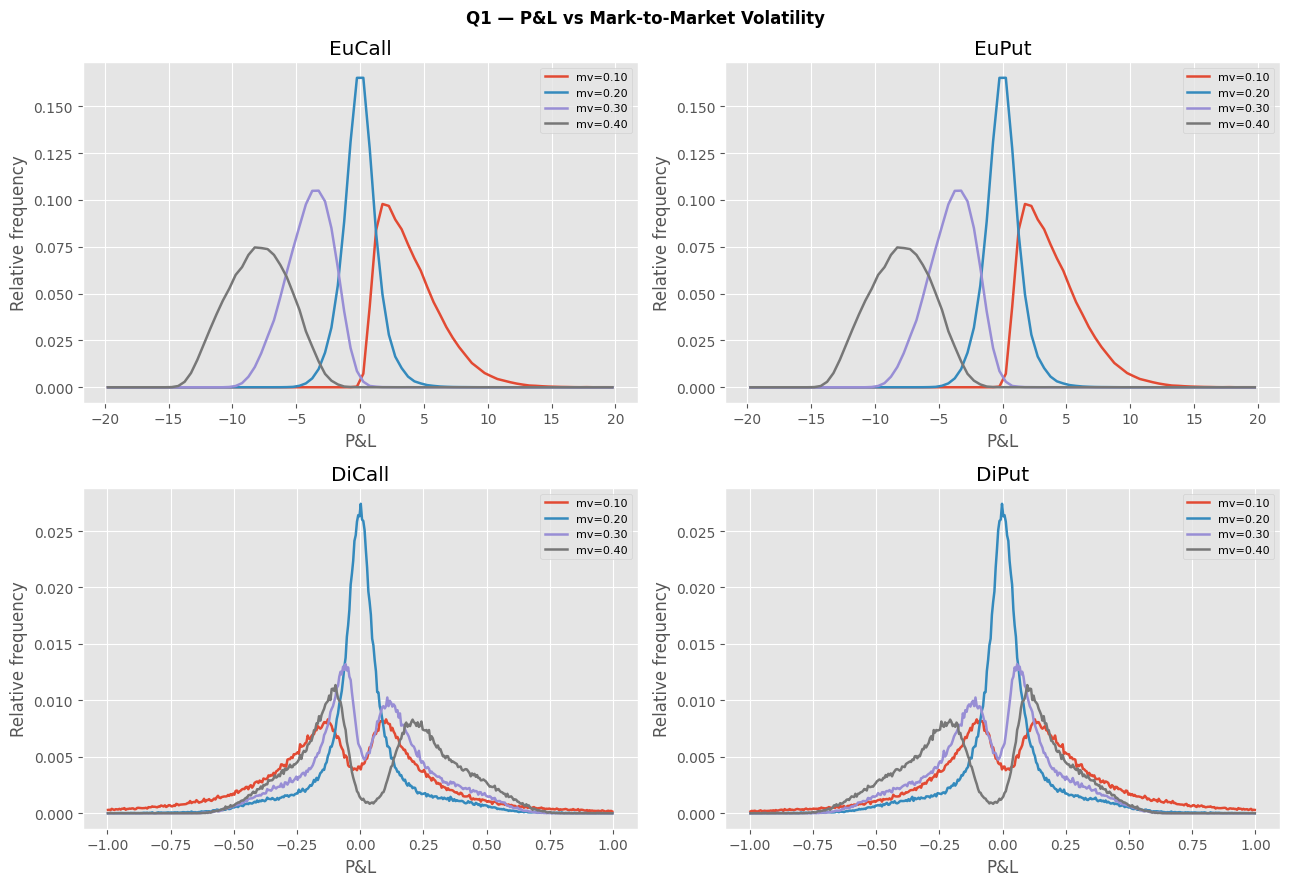

In [13]:
hedgeFreq = 24
vol_data = {}   # name -> {vol -> (mids, heights)}

for optT, payT, name in variants:
    vol_data[name] = {}
    hmin, hmax = hist_range[name]
    for mv in mtm_vols:
        out   = qf.BSHedge(optT, payT, strike, T, "flat2pct",
                            divY, spot, simVol, mv,
                            pgType, rngType, hedgeFreq, nPaths,
                            hmin, hmax, hist_nbins[name])
        edges = np.array(out['hist_edges'])
        mids  = 0.5 * (edges[:-1] + edges[1:])
        cnts  = np.array(out['hist_counts']).ravel().astype(int)
        vol_data[name][mv] = (mids, cnts / cnts.sum())

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (_, _, name) in zip(axes.flatten(), variants):
    for mv, (mids, heights) in vol_data[name].items():
        ax.plot(mids, heights, linewidth=1.8, label=f"mv={mv:.2f}")
    ax.set_title(name)
    ax.set_xlabel("P&L")
    ax.set_ylabel("Relative frequency")
    ax.legend(fontsize=8)
fig.suptitle("Q1 — P&L vs Mark-to-Market Volatility", fontweight="bold")
plt.tight_layout()
plt.show()


## Frequency Sweep
Equal vols (sim = mtm = 20%). Hedge frequency varies.

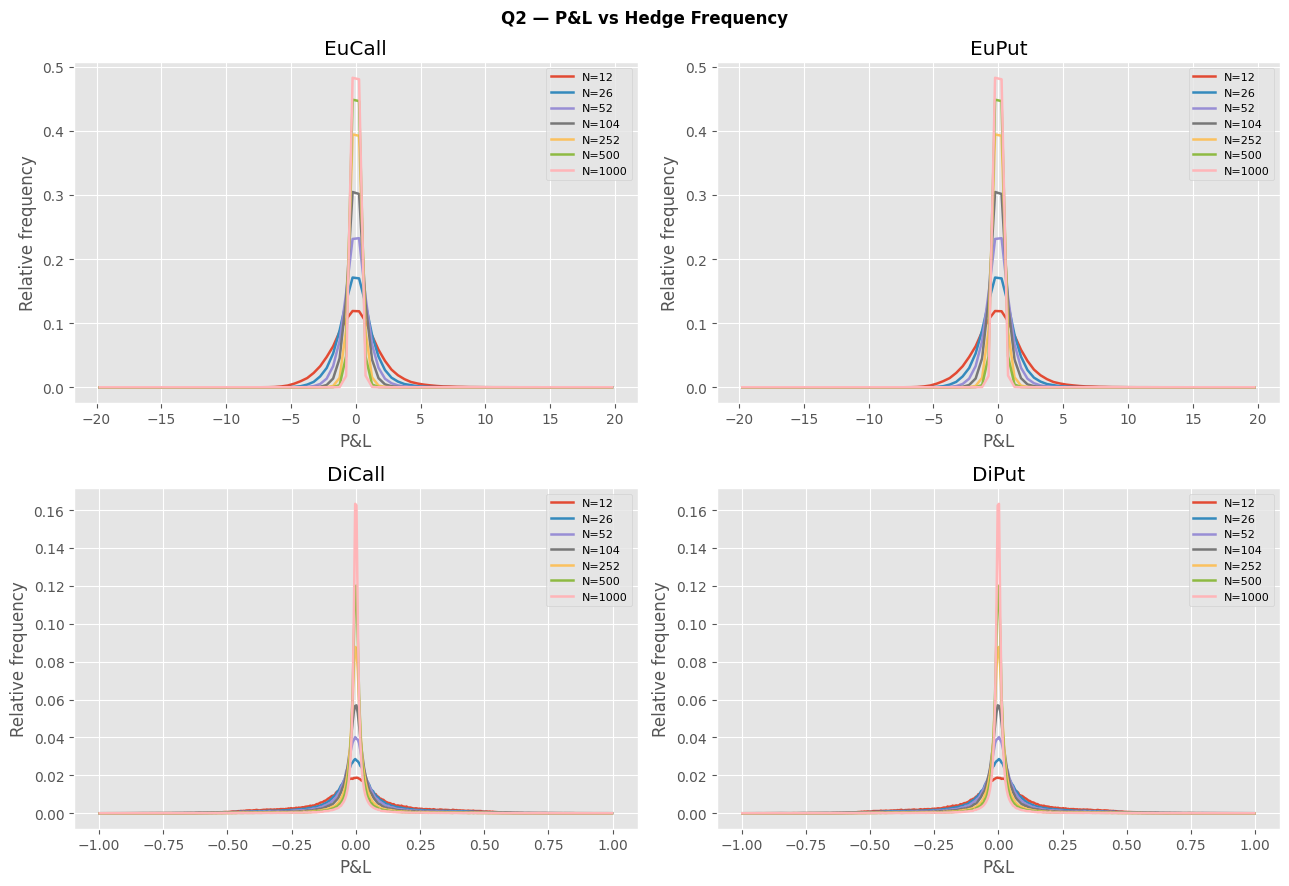

In [10]:
freq_data = {}   # name -> {freq -> (mids, heights)}
stds      = {name: [] for _, _, name in variants}

for optT, payT, name in variants:
    freq_data[name] = {}
    hmin, hmax = hist_range[name]
    for hf in freqs:
        out   = qf.BSHedge(optT, payT, strike, T, "flat2pct",
                            divY, spot, simVol, simVol,
                            pgType, rngType, hf, nPaths,
                            hmin, hmax, hist_nbins[name])
        edges = np.array(out['hist_edges'])
        mids  = 0.5 * (edges[:-1] + edges[1:])
        cnts  = np.array(out['hist_counts']).ravel().astype(int)
        heights = cnts / cnts.sum()
        freq_data[name][hf] = (mids, heights)
        samples = np.repeat(mids, cnts)
        stds[name].append(np.std(samples, ddof=1))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (_, _, name) in zip(axes.flatten(), variants):
    for hf, (mids, heights) in freq_data[name].items():
        ax.plot(mids, heights, linewidth=1.8, label=f"N={hf}")
    ax.set_title(name)
    ax.set_xlabel("P&L")
    ax.set_ylabel("Relative frequency")
    ax.legend(fontsize=8)
fig.suptitle("Q2 — P&L vs Hedge Frequency", fontweight="bold")
plt.tight_layout()
plt.show()


## Scaling Law


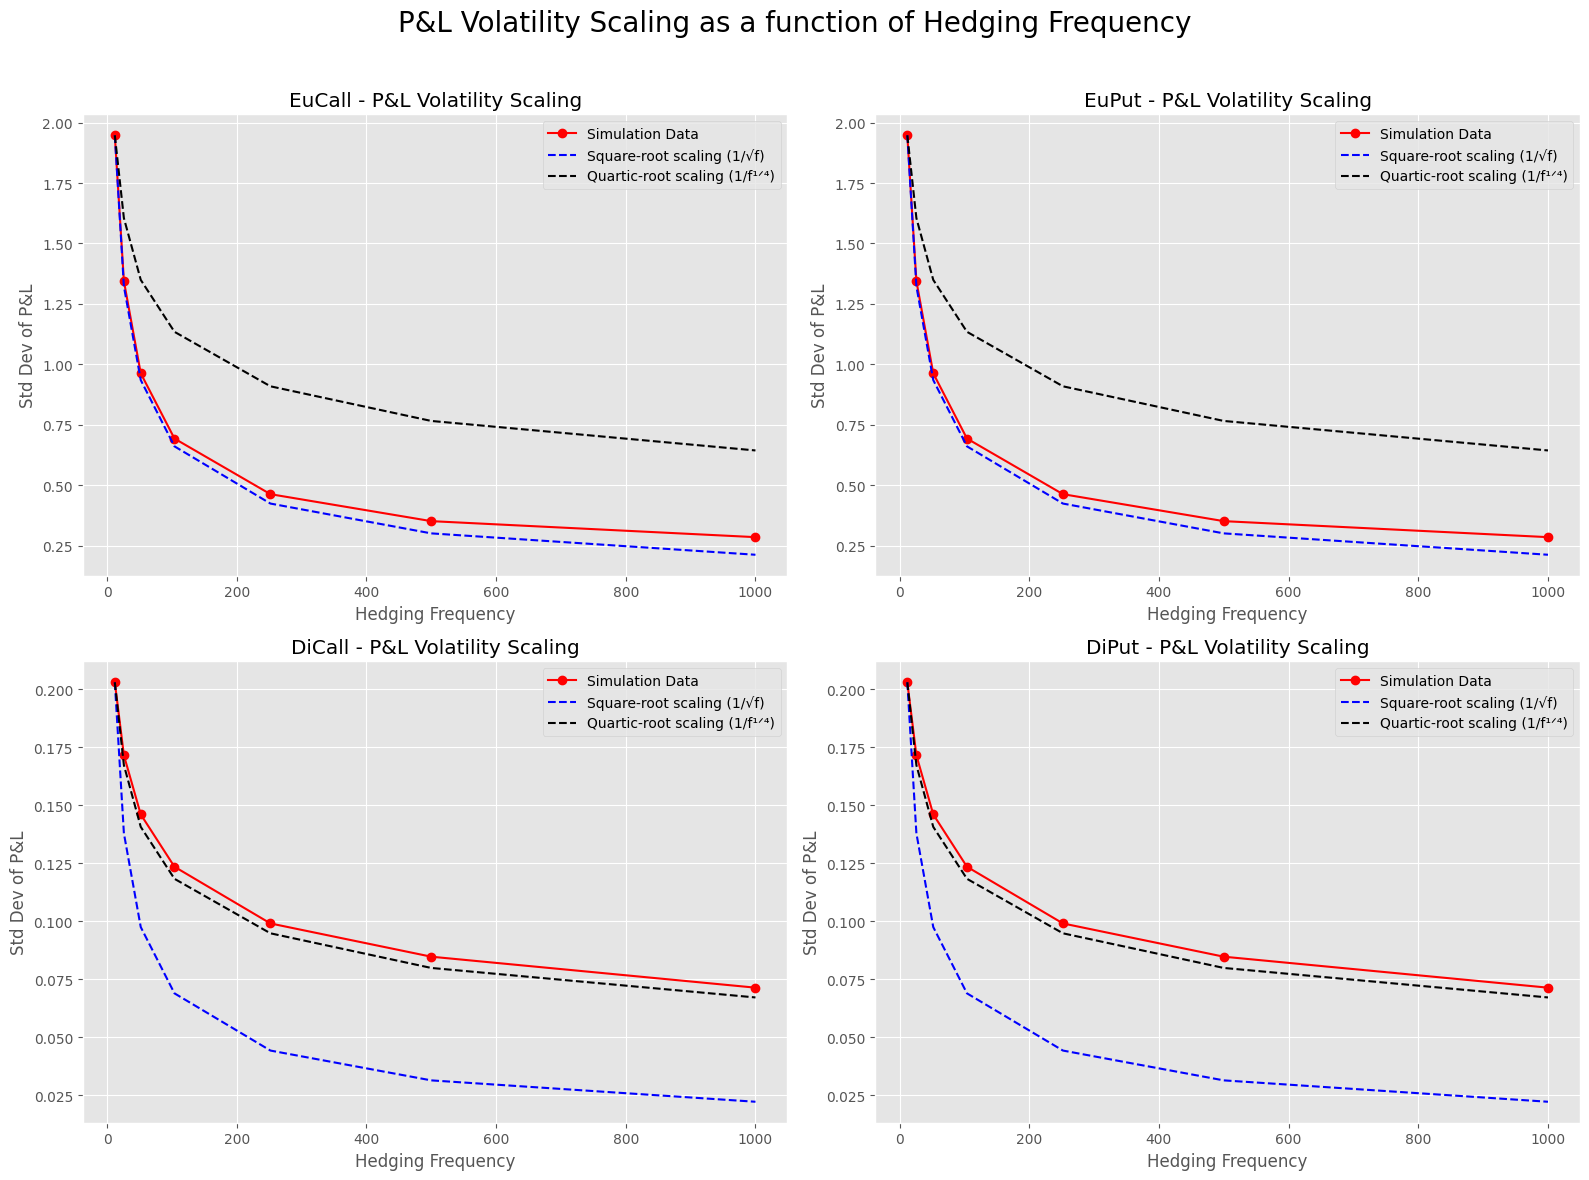

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

for idx, (_, _, name) in enumerate(variants):
    hedge_freqs = np.array(freqs, dtype=float)
    std_errors = np.array(stds[name])

    # reference scaling lines
    ref_stddev_sqrt = std_errors[0] * np.sqrt(hedge_freqs[0] / hedge_freqs)       # 1/sqrt(f)
    ref_stddev_qroot = std_errors[0] * (hedge_freqs[0] / hedge_freqs)**0.25       # 1/f^(1/4)

    ax = axs[idx]
    ax.plot(hedge_freqs, std_errors, 'ro-', label='Simulation Data')
    ax.plot(hedge_freqs, ref_stddev_sqrt, 'b--', label='Square-root scaling (1/√f)')
    ax.plot(hedge_freqs, ref_stddev_qroot, 'k--', label='Quartic-root scaling (1/f¹ᐟ⁴)')
    ax.set_title(f'{name} - P&L Volatility Scaling')
    ax.set_xlabel('Hedging Frequency')
    ax.set_ylabel('Std Dev of P&L')
    ax.grid(True)
    ax.legend()

plt.suptitle("P&L Volatility Scaling as a function of Hedging Frequency", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Export to Excel

In [12]:
output_file = "DeltaHedge_Distributions.xlsx"

def write_sheet(writer, sheet_name, data_dict, sweep_keys):
    sh = writer.book.add_worksheet(sheet_name)
    writer.sheets[sheet_name] = sh
    row = 0
    for name in [n for _,_,n in variants]:
        for key in sweep_keys:
            mids, heights = data_dict[name][key]
            cnts = (heights * nPaths).astype(int)
            df = pd.DataFrame({"mid": mids, "freq": cnts})
            df.to_excel(writer, sheet_name=sheet_name, startrow=row, index=False)
            row += len(df) + 3

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    write_sheet(writer, "Vol_Sweep",  vol_data,  mtm_vols)
    write_sheet(writer, "Freq_Sweep", freq_data, freqs)

print(f"Saved {output_file}")


Saved DeltaHedge_Distributions.xlsx
